### Notebook for verifying that implemented dynamics work correctly

In [2]:
import importlib
import Model
importlib.reload(Model)
from Model import SpeciesModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# from WolfClass import Wolf
# from DeerClass import Deer

In [3]:
def plot_headings(positions, headings, sensing_radius, animal, old_positions=np.array([]), old_headings=np.array([])):
    # Plot 
    fig, ax = plt.subplots(1,1)
    # Plot deer
    ax.scatter(deer_positions[:,0], deer_positions[:,1], c='blue', label='deer')
    # Plot wolves
    ax.scatter(positions[:,0], positions[:,1], c='red', label='wolf')

    # Plot headings
    arrow_scale = 1000    
    ax.quiver(
        positions[:,0], 
        positions[:,1], 
        headings[:,0] * arrow_scale, 
        headings[:,1] * arrow_scale, 
        width=0.003,                # Arrow shaft width
        headwidth=4,                # Arrow head width
        headlength=5,
        label='heading vector')
    
    # plot sensing radius
    for i in range(len(positions)):
        circ = plt.Circle((positions[i][0], positions[i][1]), radius=sensing_radius, edgecolor='b', facecolor='None')
        ax.add_patch(circ) 

    if len(old_headings) > 0 and len(old_positions) > 0:
        # Plot positions
        ax.scatter(old_positions[:,0], old_positions[:,1], c='red', label='previous position', alpha=0.4)
        
        ax.quiver(
            old_positions[:,0], 
            old_positions[:,1], 
            old_headings[:,0] * arrow_scale, 
            old_headings[:,1] * arrow_scale, 
            width=0.003,                # Arrow shaft width
            headwidth=4,                # Arrow head width
            headlength=5,
            alpha=0.4, 
            color='black',
            label='previous headings'
            )

    

    ax.set_title(f'Demonstrating {animal} movement')
    ax.legend(loc='upper right')
    plt.show()

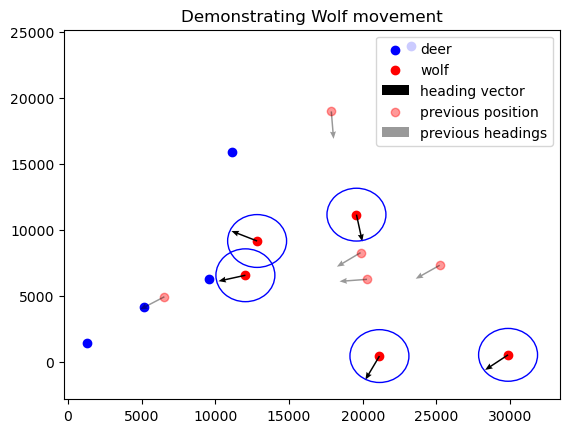

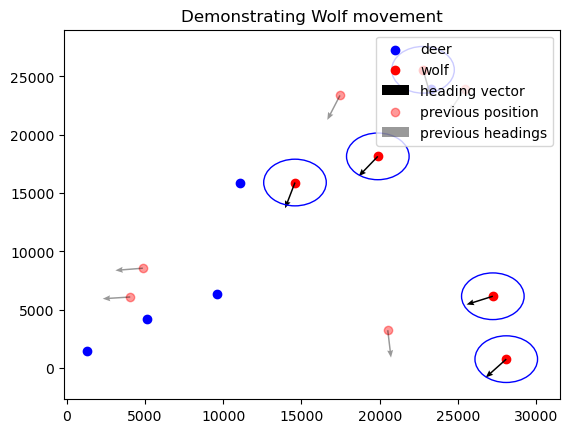

In [6]:
num_wolves = 5
num_deer = 5

# Create smaller world 
small_world = SpeciesModel(
    init_predators=num_wolves,
    init_deer = num_deer,
    height=30000,     
    width=30000,
    seed=40,
    init_num_of_packs = 3,
    predator = 'Wolf',  # Helper attribute to avoid imports when accessing agent type
    energy_decrease = 0.05,  # Energy decrease parameter 
    energy_min = 0,  # Point at which the animal will die of exhaustion
    veg_cell_size = 1,  # Introducing vegetation
    # Options to control complexity of the model
    use_pack_dynamics = True,  
    use_random_movement = False,
    use_veg = False
)

wolf_positions = []
deer_positions = []
wolves = []
deer = []
for agent in small_world.space.agents:
    x,y = agent.pos
    # check if wolf
    if agent.species == 'Wolf':
        wolf_positions.append([x,y])   
        wolves.append(agent)     
    elif agent.species == 'Deer':
        deer_positions.append([x,y])
        deer.append(agent)     

deer_positions = np.array(deer_positions)

wolf_headings = np.zeros((num_wolves,2))
for i,w in enumerate(wolves):
    wolf_headings[i] = w.heading


# Perform some steps
n_steps = 5
headings = np.zeros((n_steps,len(wolf_headings), 2))
positions = np.zeros((n_steps, len(wolf_positions),2))

for step in range(n_steps):
    # Move the wolves each step, storing their positions and headings
    for i,w in enumerate(wolves):
        w.move()
        headings[step][i] = w.heading
        x,y = w.pos
        positions[step][i] = [x,y]



plot_headings(positions[2], headings[2], wolves[0].sensing_radius, 'Wolf', positions[1], headings[1])
plot_headings(positions[4], headings[4], wolves[0].sensing_radius, 'Wolf', positions[3], headings[3])



: 